# x402: What Are Agents Actually Paying For?

Use case breakdown of x402 transaction activity by category.

Data: Artemis x402 Data (May 2025 - Apr 2026)

Scope: Classified volume only ($12.2m/$108M total). Unclassified transactions excluded.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [50]:
FILE_CAT_TXS = "/content/x402 Transactions by Category (Adjusted).csv"
FILE_CAT_VOL = "/content/Updated x402 Categorized Volume.csv"
FILE_GAMED   = "/content/x402 avg tx size vs gamed % (latest) .csv"

BG = "#0D1117"
GRID = "#21262D"
TEXT = "#E6EDF3"
MUTED = "#888888"

CATEGORIES = [
    "Agent to Agent Services",
    "Data as a Service",
    "Token Launches & Fair Mints",
    "Infrastructure & Utilities",
    "AI Generated Content",
    "Premium Content & Paywalls",
]

COLORS = {
    "Agent to Agent Services":     "#FF6B4A",
    "Data as a Service":           "#00E5A0",
    "Token Launches & Fair Mints": "#FFD700",
    "Infrastructure & Utilities":  "#7B68EE",
    "AI Generated Content":        "#00BFFF",
    "Premium Content & Paywalls":  "#FF69B4",
}

plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "font.size": 11,
    "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.grid": True, "grid.color": GRID, "grid.alpha": 0.3,
})


In [51]:
def load(path):
    df = pd.read_csv(path, encoding="utf-8-sig").fillna(0)
    df.rename(columns={df.columns[0]: "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"])
    return df

txs = load(FILE_CAT_TXS)
vol = load(FILE_CAT_VOL)
gamed = load(FILE_GAMED)
gamed.rename(columns={"Date": "date"}, inplace=True)
gamed.columns = ["date"] + list(gamed.columns[1:])
if len(gamed.columns) == 3:
    gamed.columns = ["date", "avg_tx_size", "pct_gamed"]

COL_MAP = {
    "Paywalled Content":    "Premium Content & Paywalls",
    "Data":                 "Data as a Service",
    "Utilities":            "Infrastructure & Utilities",
    "AI-Generated Content": "AI Generated Content",
    "Agent-to-Agent":       "Agent to Agent Services",
    "Token Launches":       "Token Launches & Fair Mints",
}
vol.rename(columns=COL_MAP, inplace=True)
txs.rename(columns=COL_MAP, inplace=True)


txs = txs[txs[CATEGORIES].sum(axis=1) > 0].reset_index(drop=True)
vol = vol[vol.Date.isin(txs.Date)].reset_index(drop=True)

last_full_month = txs["Date"].max().replace(day=1)
txs = txs[txs["Date"] < last_full_month].reset_index(drop=True)
vol = vol[vol["Date"] < last_full_month].reset_index(drop=True)

total_txs = txs[CATEGORIES].sum().sum()
total_vol = vol[CATEGORIES].sum().sum()

In [52]:
#stats

BG = "#0D1117"
GRID = "#21262D"
TEXT = "#E6EDF3"
MUTED = "#888888"
CARD_BG = "#161B22"

print(f"x402 Use Cases: {txs.Date.min().date()} to {txs.Date.max().date()}")
print(f"Active days: {len(txs)} | Txs: {total_txs:,.0f} | Volume: ${total_vol:,.0f}\n")

for cat in sorted(CATEGORIES, key=lambda c: vol[c].sum(), reverse=True):
    t, v = txs[cat].sum(), vol[cat].sum()
    print(f"  {cat:<30} {v/total_vol*100:>5.1f}% vol  {t/total_txs*100:>5.1f}% txs  ${v/t:.4f}/tx")

vol_monthly = vol.set_index("Date").resample("MS")[CATEGORIES].sum()
latest = vol_monthly.iloc[-1]
latest_hhi = int(((latest / latest.sum()) ** 2).sum() * 10000)

top_vol = max(CATEGORIES, key=lambda c: vol[c].sum())
top_txs = max(CATEGORIES, key=lambda c: txs[c].sum())
top_avg = max(CATEGORIES, key=lambda c: vol[c].sum() / max(txs[c].sum(), 1))

x402 Use Cases: 2025-05-11 to 2026-03-31
Active days: 309 | Txs: 97,692,804 | Volume: $12,209,673

  Agent to Agent Services         41.0% vol   39.5% txs  $0.1297/tx
  Data as a Service               29.3% vol   23.8% txs  $0.1534/tx
  Token Launches & Fair Mints     23.2% vol    5.0% txs  $0.5793/tx
  Infrastructure & Utilities       5.3% vol   30.5% txs  $0.0218/tx
  AI Generated Content             1.1% vol    1.1% txs  $0.1322/tx
  Premium Content & Paywalls       0.0% vol    0.0% txs  $0.1161/tx


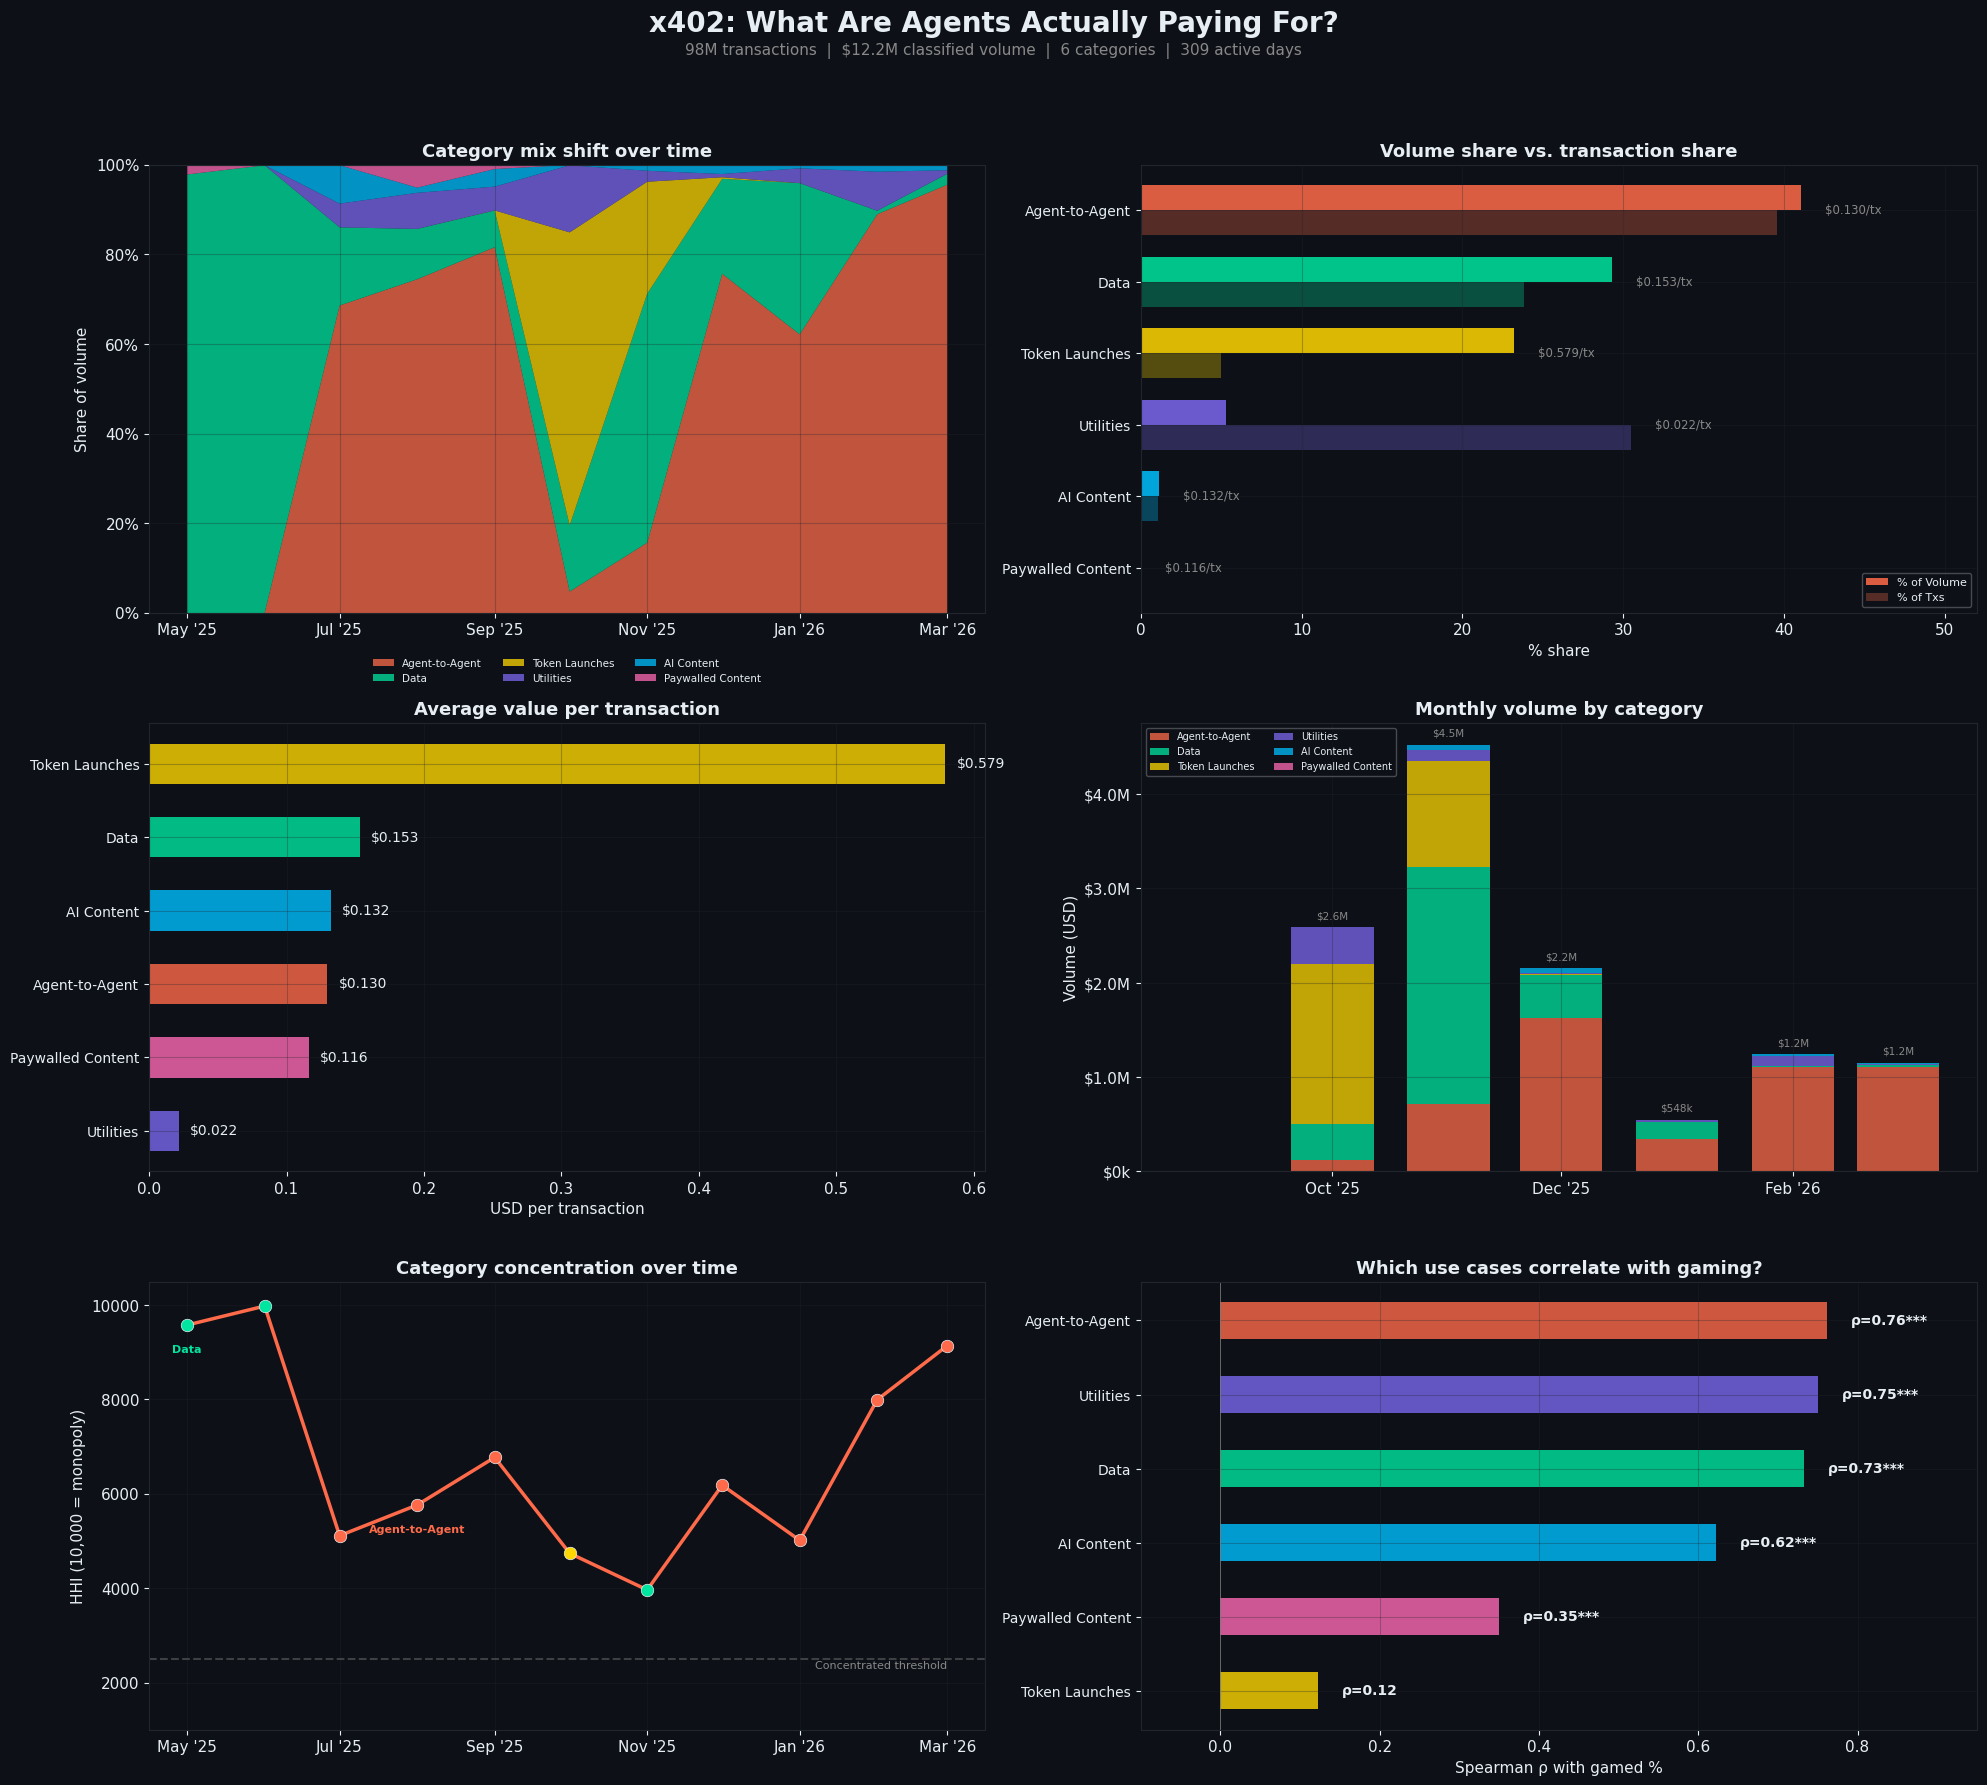

In [66]:
import matplotlib.gridspec as gridspec
from scipy import stats

SHORT = {
    "Agent to Agent Services":     "Agent-to-Agent",
    "Data as a Service":           "Data",
    "Token Launches & Fair Mints": "Token Launches",
    "Infrastructure & Utilities":  "Utilities",
    "AI Generated Content":        "AI Content",
    "Premium Content & Paywalls":  "Paywalled Content",
}

vol_monthly = vol.set_index("Date").resample("MS")[CATEGORIES].sum()

fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle("x402: What Are Agents Actually Paying For?", fontsize=20, fontweight="bold", y=0.99)
fig.text(0.5, 0.965, f"{total_txs/1e6:.0f}M transactions  |  \${total_vol/1e6:.1f}M classified volume  |  6 categories  |  {len(txs)} active days",
         ha="center", fontsize=11, color=MUTED)

# 1 - Category mix shift
ax = axes[0, 0]
vol_pct = vol_monthly.div(vol_monthly.sum(axis=1), axis=0).fillna(0)
ax.stackplot(vol_pct.index, *[vol_pct[c] for c in CATEGORIES],
             colors=[COLORS[c] for c in CATEGORIES], alpha=0.75)
ax.set_ylabel("Share of volume")
ax.set_title("Category mix shift over time")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
handles = [plt.Rectangle((0,0),1,1, fc=COLORS[c], alpha=0.75) for c in CATEGORIES]
ax.legend(handles, [SHORT[c] for c in CATEGORIES], loc="upper center",
          bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=7.5, framealpha=0)

# 2 - Volume vs Tx share
ax = axes[0, 1]
sorted_cats = sorted(CATEGORIES, key=lambda c: vol[c].sum(), reverse=True)
y_pos = np.arange(len(sorted_cats))
vol_pcts = [vol[c].sum() / total_vol * 100 for c in sorted_cats]
tx_pcts = [txs[c].sum() / total_txs * 100 for c in sorted_cats]
h = 0.35
ax.barh(y_pos - h/2, vol_pcts, h, color=[COLORS[c] for c in sorted_cats], alpha=0.85, label="% of Volume")
ax.barh(y_pos + h/2, tx_pcts, h, color=[COLORS[c] for c in sorted_cats], alpha=0.30, label="% of Txs")
for i, cat in enumerate(sorted_cats):
    v, t = vol[cat].sum(), txs[cat].sum()
    avg = v / t if t > 0 else 0
    ax.text(max(vol_pcts[i], tx_pcts[i]) + 1.5, i, f"\${avg:.3f}/tx", va="center", fontsize=8.5, color=MUTED)
ax.set_yticks(y_pos)
ax.set_yticklabels([SHORT[c] for c in sorted_cats], fontsize=10)
ax.set_xlabel("% share")
ax.set_title("Volume share vs. transaction share")
ax.legend(fontsize=8, framealpha=0.3, loc="lower right")
ax.invert_yaxis()
ax.set_xlim(0, 52)

# 3 - Avg $/tx
ax = axes[1, 0]
avg_per_tx = {c: vol[c].sum() / max(txs[c].sum(), 1) for c in CATEGORIES}
sorted_avg = sorted(avg_per_tx, key=avg_per_tx.get)
bars = ax.barh(range(len(sorted_avg)), [avg_per_tx[c] for c in sorted_avg],
               color=[COLORS[c] for c in sorted_avg], alpha=0.8, height=0.55)
for i, cat in enumerate(sorted_avg):
    ax.text(avg_per_tx[cat] + 0.008, i, f"\${avg_per_tx[cat]:.3f}", va="center", fontsize=10, color=TEXT)
ax.set_yticks(range(len(sorted_avg)))
ax.set_yticklabels([SHORT[c] for c in sorted_avg], fontsize=10)
ax.set_title("Average value per transaction")
ax.set_xlabel("USD per transaction")

# 4 - Monthly volume stacked bar
ax = axes[1, 1]
vol_monthly_f = vol_monthly[vol_monthly.sum(axis=1) > 500]
bottom = np.zeros(len(vol_monthly_f))
for cat in CATEGORIES:
    vals = vol_monthly_f[cat].values
    ax.bar(vol_monthly_f.index, vals, bottom=bottom, width=22, color=COLORS[cat], alpha=0.75)
    bottom += vals
for date, total in zip(vol_monthly_f.index, vol_monthly_f.sum(axis=1)):
    if total > 10000:
        label = f"\${total/1e6:.1f}M" if total >= 1e6 else f"\${total/1e3:.0f}k"
        ax.text(date, total + vol_monthly_f.sum(axis=1).max() * 0.02, label, ha="center", fontsize=7.5, color=MUTED)
ax.set_title("Monthly volume by category")
ax.set_ylabel("Volume (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"\${x/1e6:.1f}M" if x >= 1e6 else f"\${x/1e3:.0f}k"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
handles = [plt.Rectangle((0,0),1,1, fc=COLORS[c], alpha=0.75) for c in CATEGORIES]
ax.legend(handles, [SHORT[c] for c in CATEGORIES], loc="upper left", fontsize=7, framealpha=0.3, ncol=2)

# 5 - HHI concentration
ax = axes[2, 0]
hhis, dominants = [], []
for _, row in vol_monthly.iterrows():
    total = row.sum()
    if total == 0: hhis.append(np.nan); dominants.append(""); continue
    shares = row / total
    hhis.append((shares ** 2).sum() * 10000)
    dominants.append(shares.idxmax())
ax.plot(vol_monthly.index, hhis, color="#FF6B4A", linewidth=2.5, zorder=3)
for date, hhi, dom in zip(vol_monthly.index, hhis, dominants):
    if dom and not np.isnan(hhi):
        ax.plot(date, hhi, "o", color=COLORS.get(dom, MUTED), markersize=9, zorder=5,
                markeredgecolor=TEXT, markeredgewidth=0.5)
ax.axhline(2500, color=MUTED, linestyle="--", alpha=0.4)
ax.text(vol_monthly.index[-1], 2300, "Concentrated threshold", fontsize=8, color=MUTED, ha="right")
ax.set_ylabel("HHI (10,000 = monopoly)")
ax.set_title("Category concentration over time")
ax.set_ylim(1000, 10500)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
labeled = set()
for date, hhi, dom in zip(vol_monthly.index, hhis, dominants):
    if dom and not np.isnan(hhi) and date.month in [5, 8, 11, 2]:
        s = SHORT.get(dom, dom)
        if s not in labeled:
            ax.annotate(s, xy=(date, hhi), xytext=(0, -20), textcoords="offset points",
                        fontsize=8, color=COLORS.get(dom, TEXT), ha="center", fontweight="bold")
            labeled.add(s)

# 6 - Correlation with gaming
ax = axes[2, 1]
gamed_clean = gamed[gamed["avg_tx_size"] > 0].copy()
merged = txs.merge(gamed_clean[["date", "pct_gamed"]], left_on="Date", right_on="date", how="inner")
corr_results = []
for cat in CATEGORIES:
    active = merged[merged[cat] > 0]
    if len(active) < 10:
        continue
    rho, p = stats.spearmanr(active[cat], active["pct_gamed"])
    corr_results.append({"cat": cat, "rho": rho, "p": p})
corr_results = sorted(corr_results, key=lambda x: x["rho"])
cats_sorted = [r["cat"] for r in corr_results]
rhos = [r["rho"] for r in corr_results]
ax.barh(range(len(cats_sorted)), rhos, color=[COLORS[c] for c in cats_sorted], alpha=0.8, height=0.5)
ax.axvline(0, color=MUTED, linewidth=0.5)
for i, r in enumerate(corr_results):
    sig = "***" if r["p"] < 0.001 else "**" if r["p"] < 0.01 else "*" if r["p"] < 0.05 else ""
    ax.text(r["rho"] + 0.03, i, f"\u03c1={r['rho']:.2f}{sig}", va="center", fontsize=10, color=TEXT, fontweight="bold")
ax.set_yticks(range(len(cats_sorted)))
ax.set_yticklabels([SHORT[c] for c in cats_sorted], fontsize=10)
ax.set_xlabel("Spearman \u03c1 with gamed %")
ax.set_title("Which use cases correlate with gaming?")
ax.set_xlim(-0.1, 0.95)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("x402_usecase_analysis.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()